# Subquestion 1: Behavioral Differences and Layout Effects
**Objective:** Determine if differences in click-through rates between DQA-present and standard sessions are statistically significant, and analyze how these differences vary across ranking positions and column placements.

In [57]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
import random

def set_deterministic_seed(seed=42):
    """Locks down randomness for base Python and NumPy."""
    # 1. Base Python
    random.seed(seed)
    
    # 2. Environment (Dictionary hashing)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. NumPy
    np.random.seed(seed)
    
    print(f"Global deterministic seed set to {seed}.")

# Execute immediately
set_deterministic_seed(42)

# Ensure the src module can be imported from the notebooks directory
sys.path.append(os.path.abspath('..'))
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

FIGURE_SIZE = (10, 6)
PANEL_FIGURE_HEIGHT = 4.8
PANEL_FIGURE_ASPECT = 1.1
AXIS_LABEL_SIZE = 12
TICK_LABEL_SIZE = 11
LEGEND_FONT_SIZE = 11
FACET_TITLE_SIZE = 12
FIG2_AXIS_LABEL_SIZE = 20
FIG2_TICK_LABEL_SIZE = 14
FIG2_LEGEND_FONT_SIZE = 20
FIG2_FACET_TITLE_SIZE = 20
LINE_WIDTH = 2
MARKER_SIZE = 7
GRID_ALPHA = 0.5
EXPORT_DPI = 300
THESIS_RC = {
    'font.size': TICK_LABEL_SIZE,
    'axes.labelsize': AXIS_LABEL_SIZE,
    'axes.titlesize': FACET_TITLE_SIZE,
    'xtick.labelsize': TICK_LABEL_SIZE,
    'ytick.labelsize': TICK_LABEL_SIZE,
    'legend.fontsize': LEGEND_FONT_SIZE,
    'legend.title_fontsize': LEGEND_FONT_SIZE,
}
FIG2_RC = {
    'font.size': FIG2_TICK_LABEL_SIZE,
    'axes.labelsize': FIG2_AXIS_LABEL_SIZE,
    'axes.titlesize': FIG2_FACET_TITLE_SIZE,
    'xtick.labelsize': FIG2_TICK_LABEL_SIZE,
    'ytick.labelsize': FIG2_TICK_LABEL_SIZE,
    'legend.fontsize': FIG2_LEGEND_FONT_SIZE,
    'legend.title_fontsize': FIG2_LEGEND_FONT_SIZE,
}
from src.data_preprocessing import get_behavioral_datasets

# Set plotting style for publication-ready graphs
sns.set_theme(style="whitegrid", rc=THESIS_RC)
plt.rcParams.update(THESIS_RC)

Global deterministic seed set to 42.


In [58]:
# Load the datasets specifically prepared for SQ1 & SQ2 (Three-way merge)
base_imp, dqa_imp = get_behavioral_datasets()

print(f"Standard Baseline Impressions: {len(base_imp):,}")
print(f"DQA-Present Impressions: {len(dqa_imp):,}")

Downloading/Loading Qilin from HuggingFace...
Partitioning DQA and merging behavioral baseline...
Flattening to impression level...
SQ1/SQ2 Baseline Impressions: 1029300
SQ1/SQ2 DQA-Present Impressions: 27656
Standard Baseline Impressions: 1,029,300
DQA-Present Impressions: 27,656


### 1. Aggregate CTR Comparison
First, we test if the DQA module significantly changes the *total* amount of clicks occurring on the page.

In [59]:
# Number of clicks (successes)
clicks_base = base_imp['click'].sum()
clicks_dqa = dqa_imp['click'].sum()

# Total number of impressions (trials)
nobs_base = len(base_imp)
nobs_dqa = len(dqa_imp)

# Calculate Overall CTR
ctr_base = clicks_base / nobs_base
ctr_dqa = clicks_dqa / nobs_dqa

# Run the Z-test
stat, pval = proportions_ztest([clicks_base, clicks_dqa], [nobs_base, nobs_dqa])

print(f"Standard Baseline CTR: {ctr_base:.4%}")
print(f"DQA-Present CTR:       {ctr_dqa:.4%}")
print("-" * 30)
print(f"Two-Proportion Z-Statistic: {stat:.4f}")
print(f"P-value:                    {pval:.4f}")

if pval < 0.05:
    print("\nConclusion: The overall CTR difference IS statistically significant.")
else:
    print("\nConclusion: The overall CTR difference IS NOT statistically significant (p >= 0.05).")

Standard Baseline CTR: 21.0229%
DQA-Present CTR:       20.7261%
------------------------------
Two-Proportion Z-Statistic: 1.1958
P-value:                    0.2318

Conclusion: The overall CTR difference IS NOT statistically significant (p >= 0.05).


### 2. Granular Positional Analysis
Since the aggregate CTR difference is not significant, we break down the CTR rank-by-rank. We calculate Cohen's $h$ to measure the practical effect size of the differences at each position.

,Position,Base_CTR,DQA_CTR,Diff (Base-DQA),p_value,Cohen_h,Significant (p<0.05)
0,1,0.6269,0.3880,0.2389,0.0000,0.4825,True
1,2,0.3754,0.2711,0.1043,0.0000,0.2237,True
2,3,0.2405,0.2023,0.0383,0.0000,0.0922,True
3,4,0.2899,0.2519,0.0380,0.0002,0.0856,True
4,5,0.2588,0.2334,0.0254,0.0320,0.0590,True
5,6,0.2536,0.2336,0.0200,0.1057,0.0465,False
6,7,0.2233,0.2054,0.0178,0.1688,0.0434,False
7,8,0.2143,0.2039,0.0104,0.4220,0.0256,False
8,9,0.1819,0.1607,0.0212,0.1102,0.0564,False
9,10,0.1693,0.1370,0.0322,0.0128,0.0896,True


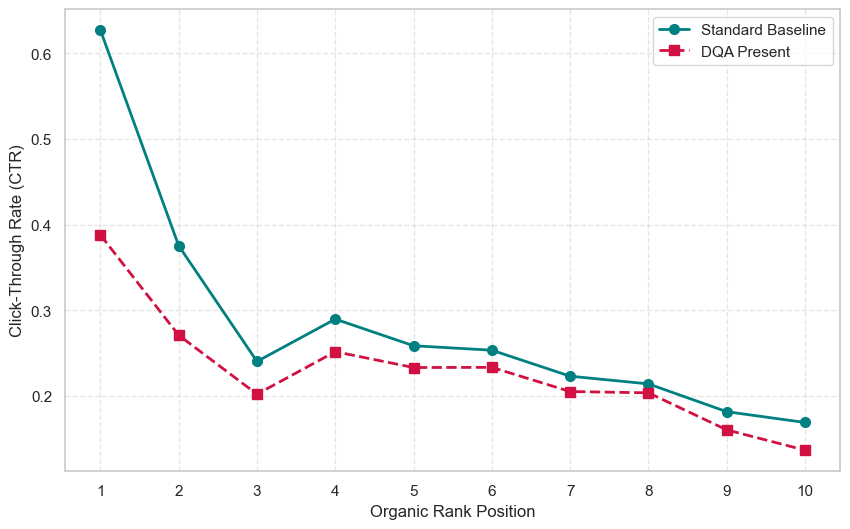

In [60]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

# Set max position to analyze (Top 10 is standard for SERP analysis)
MAX_POS = 10
results = []

for pos in range(1, MAX_POS + 1):
    base_pos = base_imp[base_imp['position'] == pos]
    dqa_pos = dqa_imp[dqa_imp['position'] == pos]
    
    if len(base_pos) == 0 or len(dqa_pos) == 0:
        continue
        
    # Get click counts and totals
    clicks_base, nobs_base = base_pos['click'].sum(), len(base_pos)
    clicks_dqa, nobs_dqa = dqa_pos['click'].sum(), len(dqa_pos)
    
    # Calculate CTR
    p_base = clicks_base / nobs_base if nobs_base > 0 else 0
    p_dqa = clicks_dqa / nobs_dqa if nobs_dqa > 0 else 0
    
    # Run Two-Proportion Z-Test
    counts = np.array([clicks_base, clicks_dqa])
    nobs = np.array([nobs_base, nobs_dqa])
    stat, pval = proportions_ztest(counts, nobs)
    
    # Calculate Cohen's h (Effect Size)
    h = 2 * (np.arcsin(np.sqrt(p_base)) - np.arcsin(np.sqrt(p_dqa)))
    
    results.append({
        'Position': pos,
        'Base_CTR': round(p_base, 4),
        'DQA_CTR': round(p_dqa, 4),
        'Diff (Base-DQA)': round(p_base - p_dqa, 4),
        'p_value': round(pval, 4),
        'Cohen_h': round(h, 4),
        'Significant (p<0.05)': pval < 0.05
    })

pos_stats_df = pd.DataFrame(results)
display(pos_stats_df)

# Plotting the CTR decay
plt.figure(figsize=FIGURE_SIZE)
plt.plot(pos_stats_df['Position'], pos_stats_df['Base_CTR'], marker='o', markersize=MARKER_SIZE,
         linewidth=LINE_WIDTH, label='Standard Baseline', color='#008080')
plt.plot(pos_stats_df['Position'], pos_stats_df['DQA_CTR'], marker='s', markersize=MARKER_SIZE,
         linewidth=LINE_WIDTH, linestyle='--', label='DQA Present', color='#D11141')
plt.xlabel('Organic Rank Position', fontsize=AXIS_LABEL_SIZE)
plt.ylabel('Click-Through Rate (CTR)', fontsize=AXIS_LABEL_SIZE)
plt.xticks(range(1, MAX_POS + 1), fontsize=TICK_LABEL_SIZE)
plt.yticks(fontsize=TICK_LABEL_SIZE)
plt.legend(fontsize=LEGEND_FONT_SIZE)
plt.grid(True, linestyle='--', alpha=GRID_ALPHA)
plt.savefig(FIGURES_DIR / 'Fig_1_CTR_decay.pdf', format='pdf', bbox_inches='tight', dpi=EXPORT_DPI)
plt.show()

### 3. Horizontal Layout Analysis (Row & Column Bias)
We translate the 1D position into a 2D layout (Row and Column) to visualize how the DQA module alters horizontal scanning behavior (e.g., checking for diagonal scanning anomalies).

In [61]:
def assign_layout(df):
    df_mapped = df.copy()
    df_mapped['row'] = (df_mapped['position'] + 1) // 2
    # Odd = Left, Even = Right
    df_mapped['column'] = np.where(df_mapped['position'] % 2 != 0, 'Left', 'Right')
    return df_mapped

# Map top 10 positions (First 5 Rows)
base_layout = assign_layout(base_imp[base_imp['position'] <= 10])
dqa_layout = assign_layout(dqa_imp[dqa_imp['position'] <= 10])

# Aggregate CTR by Row and Column
base_row_ctr = base_layout.groupby(['row', 'column'])['click'].mean().reset_index()
base_row_ctr['Environment'] = 'Standard Baseline'

dqa_row_ctr = dqa_layout.groupby(['row', 'column'])['click'].mean().reset_index()
dqa_row_ctr['Environment'] = 'DQA Present'

layout_ctr = pd.concat([base_row_ctr, dqa_row_ctr])
layout_ctr['click_pct'] = layout_ctr['click'] * 100


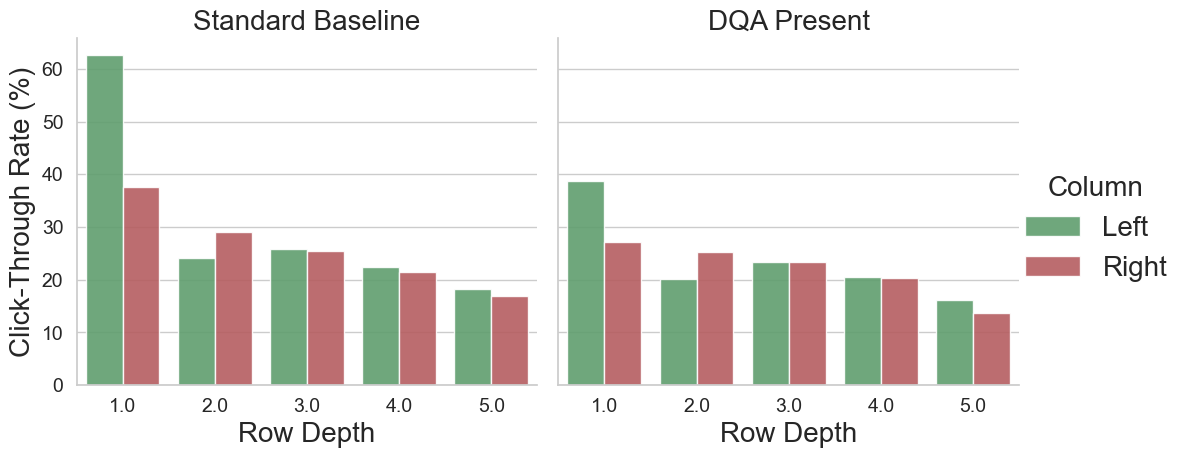

In [62]:
sns.set_theme(style="whitegrid", rc=FIG2_RC)
g = sns.catplot(
    data=layout_ctr, kind="bar",
    x="row", y="click_pct", hue="column", col="Environment",
    palette={"Left": "#55A868", "Right": "#C44E52"},
    height=PANEL_FIGURE_HEIGHT, aspect=PANEL_FIGURE_ASPECT, alpha=0.9
)

g.set_axis_labels("Row Depth", "Click-Through Rate (%)", fontsize=FIG2_AXIS_LABEL_SIZE)
g.set_titles("{col_name}", size=FIG2_FACET_TITLE_SIZE)
g.tick_params(axis="both", labelsize=FIG2_TICK_LABEL_SIZE)
if g._legend is not None:
    g._legend.set_title("Column")
    plt.setp(g._legend.get_title(), fontsize=FIG2_LEGEND_FONT_SIZE)
    plt.setp(g._legend.get_texts(), fontsize=FIG2_LEGEND_FONT_SIZE)
plt.savefig(FIGURES_DIR / 'Fig_2_layout_bias_sq1.pdf', format='pdf', bbox_inches='tight', dpi=EXPORT_DPI)
plt.show()